<a href="https://colab.research.google.com/github/asfiya-tehmeen/king-county-house-price-analysis/blob/main/House_Sales_Solved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
%matplotlib inline

In [2]:
file_name = 'https://raw.githubusercontent.com/rashida048/Datasets/master/home_data.csv'
df = pd.read_csv(file_name)
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


### Question 1
Display the data types of each column using the function dtypes.

In [3]:
df.dtypes

,0
id,int64
date,object
price,int64
bedrooms,int64
bathrooms,float64
sqft_living,int64
sqft_lot,int64
floors,float64
waterfront,int64
view,int64


### Question 2
Drop columns `id` and `Unnamed: 0`, then describe.

In [5]:
df.drop(['id', 'Unnamed: 0'], axis=1, inplace=True)
df.describe()

KeyError: "['Unnamed: 0'] not found in axis"

In [6]:
print('NaN bedrooms:', df['bedrooms'].isnull().sum())
print('NaN bathrooms:', df['bathrooms'].isnull().sum())

df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].mean())
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].mean())

print('After fix - NaN bedrooms:', df['bedrooms'].isnull().sum())
print('After fix - NaN bathrooms:', df['bathrooms'].isnull().sum())

NaN bedrooms: 0
NaN bathrooms: 0
After fix - NaN bedrooms: 0
After fix - NaN bathrooms: 0


### Question 3
Use `value_counts` to count houses with unique floor values, convert to dataframe.

In [7]:
df['floors'].value_counts().to_frame()

,count
floors,
1.0,10680
2.0,8241
1.5,1910
3.0,613
2.5,161
3.5,8


### Question 4
Boxplot: waterfront view vs price outliers.

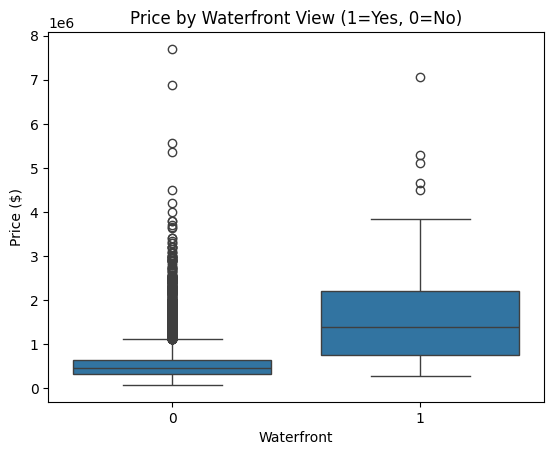

In [8]:
sns.boxplot(x='waterfront', y='price', data=df)
plt.title('Price by Waterfront View (1=Yes, 0=No)')
plt.xlabel('Waterfront')
plt.ylabel('Price ($)')
plt.show()
# Conclusion: Houses WITH a waterfront view (1) have significantly more
# price outliers and a much higher median price than those without (0).

### Question 5
Regplot: is sqft_above positively or negatively correlated with price?

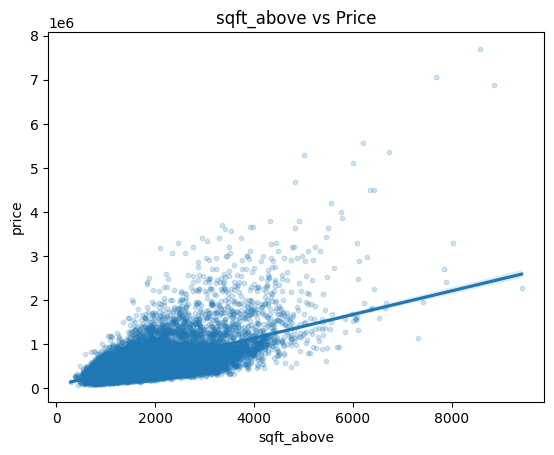

Correlation: 0.6056  => sqft_above is POSITIVELY correlated with price


In [9]:
sns.regplot(x='sqft_above', y='price', data=df, scatter_kws={'alpha': 0.2, 's': 10})
plt.title('sqft_above vs Price')
plt.show()
corr = df[['sqft_above', 'price']].corr()['price']['sqft_above']
print(f'Correlation: {corr:.4f}  => sqft_above is POSITIVELY correlated with price')

In [10]:
df.corr(numeric_only=True)['price'].sort_values()
# sqft_living has the highest correlation with price (0.702)

,price
zipcode,-0.053203
id,-0.016762
long,0.021626
condition,0.036362
yr_built,0.054012
sqft_lot15,0.082447
sqft_lot,0.089661
yr_renovated,0.126434
floors,0.256794
waterfront,0.266369


### Question 6
Linear regression using sqft_living; calculate R².

In [11]:
X = df[['sqft_living']]
Y = df['price']
lm = LinearRegression()
lm.fit(X, Y)
r2 = lm.score(X, Y)
print(f'R² (sqft_living): {r2:.4f}')

R² (sqft_living): 0.4929


### Question 7
Multi-feature linear regression; calculate R².

In [12]:
features = ["floors","waterfront","lat","bedrooms","sqft_basement","view",
            "bathrooms","sqft_living15","sqft_above","grade","sqft_living"]
X = df[features]
Y = df['price']
lm2 = LinearRegression()
lm2.fit(X, Y)
r2_multi = lm2.score(X, Y)
print(f'R² (multiple features): {r2_multi:.4f}')

R² (multiple features): 0.6577


### Question 8
Pipeline: StandardScaler + PolynomialFeatures + LinearRegression.

In [13]:
Input = [('scale', StandardScaler()),
         ('polynomial', PolynomialFeatures(include_bias=False)),
         ('model', LinearRegression())]
pipe = Pipeline(Input)
pipe.fit(X, Y)
r2_pipe = pipe.score(X, Y)
print(f'R² (Pipeline with PolynomialFeatures): {r2_pipe:.4f}')

R² (Pipeline with PolynomialFeatures): 0.7513


In [14]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.linear_model import Ridge

features = ["floors","waterfront","lat","bedrooms","sqft_basement","view",
            "bathrooms","sqft_living15","sqft_above","grade","sqft_living"]
X = df[features]
Y = df['price']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.15, random_state=1)
print('Test samples:', x_test.shape[0])
print('Training samples:', x_train.shape[0])

Test samples: 3242
Training samples: 18371


### Question 9
Ridge regression (alpha=0.1); calculate R² on test data.

In [15]:
ridge = Ridge(alpha=0.1)
ridge.fit(x_train, y_train)
r2_ridge = ridge.score(x_test, y_test)
print(f'R² Ridge (alpha=0.1): {r2_ridge:.4f}')

R² Ridge (alpha=0.1): 0.6480


### Question 10
2nd-order Polynomial transform on train/test + Ridge regression (alpha=0.1).

In [16]:
poly = PolynomialFeatures(degree=2, include_bias=False)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

ridge2 = Ridge(alpha=0.1)
ridge2.fit(x_train_poly, y_train)
r2_poly_ridge = ridge2.score(x_test_poly, y_test)
print(f'R² Polynomial(degree=2) + Ridge (alpha=0.1): {r2_poly_ridge:.4f}')

R² Polynomial(degree=2) + Ridge (alpha=0.1): 0.7004
